 KPIs

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
import seaborn as sns
sns.set_theme(style="whitegrid", palette="muted")
import warnings
warnings.filterwarnings('ignore')

SAMA_COLORS = {
    'Saudia': '#006B3F', 'Flynas': '#7B2D8E', 'Flyadeal': '#E31837',
    'primary': '#1B3A5C', 'secondary': '#2E86AB',
    'positive': '#2ECC71', 'negative': '#E74C3C', 'neutral': '#F39C12',
}
airport_names = {'RUH':'Riyadh','JED':'Jeddah','DMM':'Dammam','MED':'Madinah','AHB':'Abha','GIZ':'Jazan'}



In [ ]:
df = pd.read_excel("/content/SAMA_Clean_Dataset (1).xlsx")
print(f"Dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Airlines: {df['Airline_Name'].value_counts().to_dict()}")

Dataset: 40,000 rows × 57 columns
Airlines: {'Saudia': 18016, 'Flynas': 14054, 'Flyadeal': 7930}


Comparative Analysis of Airlines

In [ ]:
airline_kpis = df.groupby('Airline_Name').agg(
    total_flights=('Flight_ID', 'count'),
    ontime_pct=('Flight_Status', lambda x: (x=='On-time').mean()*100),
    delayed_pct=('Flight_Status', lambda x: (x=='Delayed').mean()*100),
    cancelled_pct=('Flight_Status', lambda x: (x=='Cancelled').mean()*100),
    avg_delay_min=('Delay_Minutes', 'mean'),
    avg_delay_when_delayed=('Delay_Minutes', lambda x: x[x>0].mean() if (x>0).any() else 0),
    avg_satisfaction=('Satisfaction_Index', 'mean'),
    positive_pct=('Sentiment_Category', lambda x: (x=='إيجابي').mean()*100),
    avg_efficiency=('Operational_Efficiency_Score', 'mean'),
    avg_service_rating=('Onboard_Service_Rating', 'mean'),
    avg_checkin=('Checkin_Time_Minutes', 'mean'),
    avg_boarding=('Boarding_Time_Minutes', 'mean'),
    avg_baggage=('Baggage_Claim_Time_Minutes', 'mean'),
    avg_total_wait=('Total_Wait_Minutes', 'mean'),
    avg_load_factor=('Load_Factor', 'mean'),
    complaint_rate=('Complaints_Logged', lambda x: (x>0).mean()*100),
    issue_rate=('Issue_Flag', 'mean'),
).round(2)

print("Airline KPIs:")
print(airline_kpis.T.to_string())

Airline KPIs:
Airline_Name            Flyadeal    Flynas    Saudia
total_flights            7930.00  14054.00  18016.00
ontime_pct                 68.99     69.02     69.19
delayed_pct                20.01     20.04     19.73
cancelled_pct              11.00     10.94     11.08
avg_delay_min              12.31     12.98     12.27
avg_delay_when_delayed     61.51     64.78     62.19
avg_satisfaction           62.92     62.74     62.92
positive_pct               47.62     47.59     46.81
avg_efficiency             70.21     70.08     70.22
avg_service_rating          3.88      3.87      3.88
avg_checkin                19.27     19.35     19.23
avg_boarding               28.53     28.63     28.52
avg_baggage                32.54     32.72     32.67
avg_total_wait             80.35     80.70     80.41
avg_load_factor            76.82     77.13     77.12
complaint_rate             20.71     21.02     20.57
issue_rate                  0.18      0.17      0.18


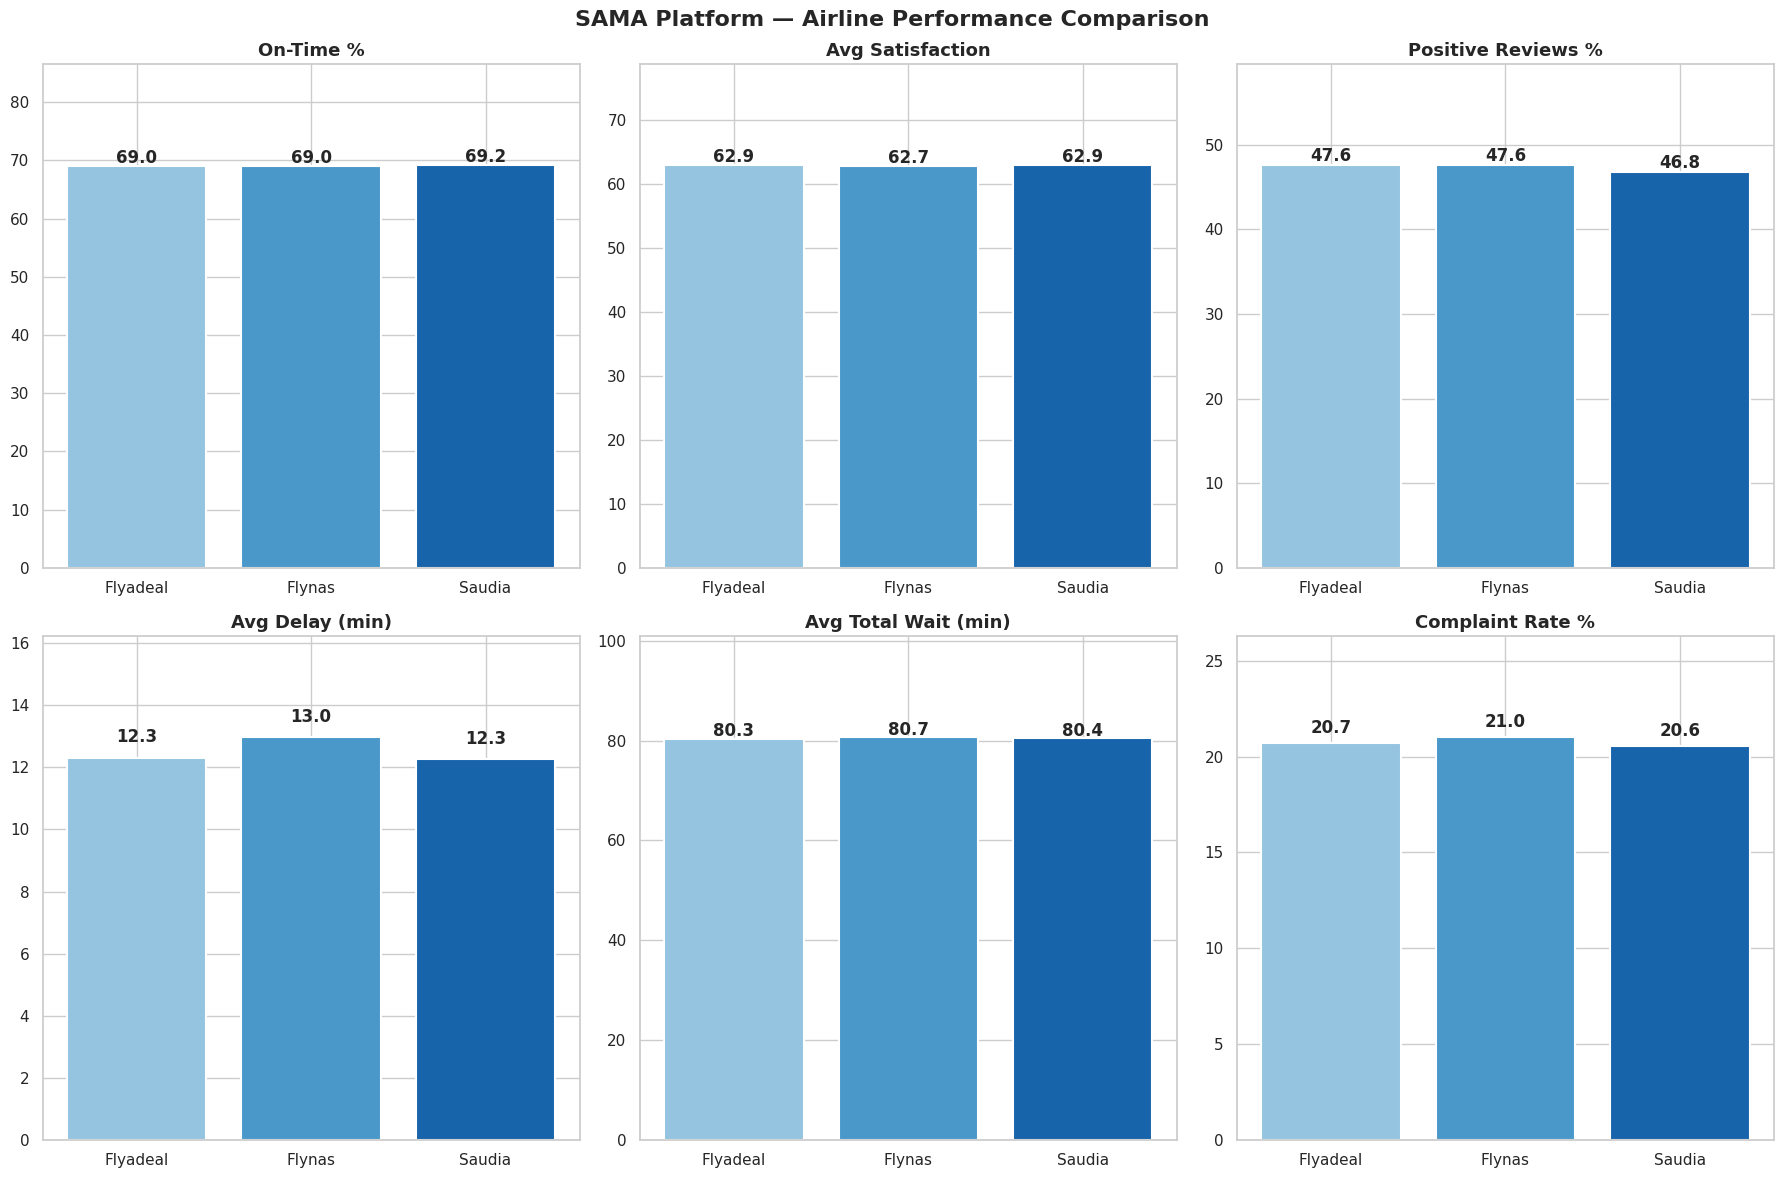

In [ ]:


fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('SAMA Platform — Airline Performance Comparison', fontsize=16, fontweight='bold')

metrics = [
    ('ontime_pct', 'On-Time %'),
    ('avg_satisfaction', 'Avg Satisfaction'),
    ('positive_pct', 'Positive Reviews %'),
    ('avg_delay_min', 'Avg Delay (min)'),
    ('avg_total_wait', 'Avg Total Wait (min)'),
    ('complaint_rate', 'Complaint Rate %'),
]

airlines = airline_kpis.index.tolist()


colors = plt.cm.Blues(np.linspace(0.4, 0.8, len(airlines)))

for idx, (col, title) in enumerate(metrics):
    ax = axes[idx//3][idx%3]
    values = airline_kpis[col].values

    bars = ax.bar(airlines, values, color=colors, edgecolor='white', linewidth=1.5)

    ax.set_title(title, fontsize=13, fontweight='bold')

    for bar, val in zip(bars, values):
        ax.text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.5,
                f'{val:.1f}', ha='center', fontweight='bold')

    ax.set_ylim(0, max(values)*1.25)

plt.tight_layout()
plt.savefig('airline_comparison_blue.png', dpi=150, bbox_inches='tight')
plt.show()

Flight Delay Analysis

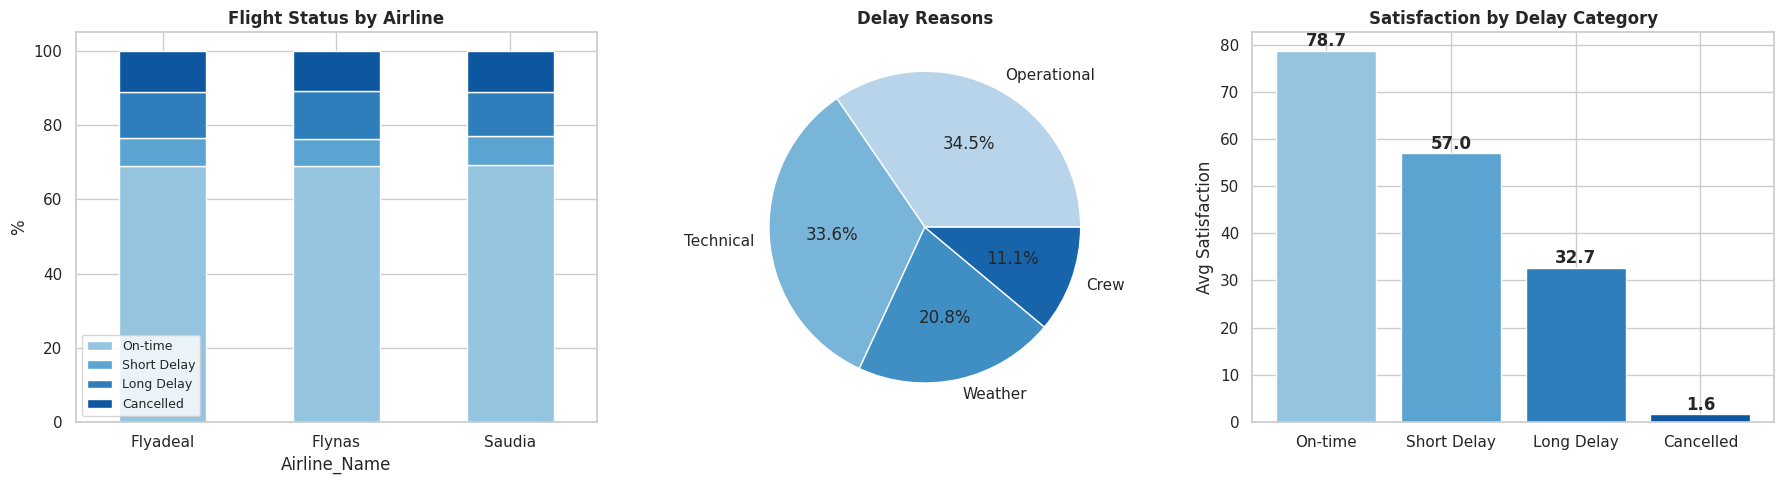

In [ ]:


fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# الازرق
blue_palette = plt.cm.Blues(np.linspace(0.4, 0.85, 4))

# 1) Flight Status by Airline (stacked bar)
delay_by_airline = pd.crosstab(df['Airline_Name'], df['Delay_Category'], normalize='index') * 100
cat_order = [c for c in ['On-time','Short Delay','Long Delay','Cancelled'] if c in delay_by_airline.columns]

delay_by_airline[cat_order].plot(
    kind='bar',
    stacked=True,
    ax=axes[0],
    color=blue_palette[:len(cat_order)]  # 🔵 ألوان زرقاء
)

axes[0].set_title('Flight Status by Airline', fontweight='bold')
axes[0].set_ylabel('%')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(fontsize=9)

# 2) Delay Reasons (pie chart)
reasons = df[df['Delay_Reason']!='No Delay']['Delay_Reason'].value_counts()

pie_colors = plt.cm.Blues(np.linspace(0.3, 0.8, len(reasons)))

axes[1].pie(
    reasons.values,
    labels=reasons.index,
    autopct='%1.1f%%',
    colors=pie_colors
)

axes[1].set_title('Delay Reasons', fontweight='bold')

# 3) Satisfaction by Delay Category (bar chart)
cats = ['On-time','Short Delay','Long Delay','Cancelled']
sat_vals = [df[df['Delay_Category']==c]['Satisfaction_Index'].mean() for c in cats]

bars = axes[2].bar(
    cats,
    sat_vals,
    color=blue_palette[:len(cats)]  # 🔵 نفس التدرج
)

axes[2].set_title('Satisfaction by Delay Category', fontweight='bold')
axes[2].set_ylabel('Avg Satisfaction')

for bar, val in zip(bars, sat_vals):
    axes[2].text(
        bar.get_x()+bar.get_width()/2.,
        bar.get_height()+1,
        f'{val:.1f}',
        ha='center',
        fontweight='bold'
    )

plt.tight_layout()
plt.savefig('delay_analysis_blue.png', dpi=150, bbox_inches='tight')
plt.show()

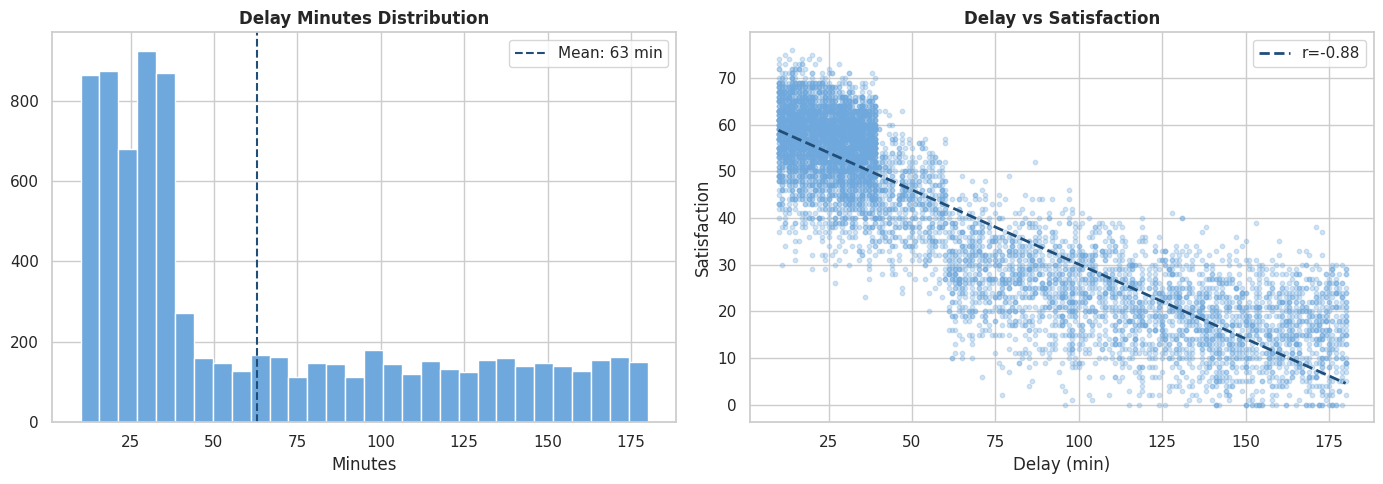

In [ ]:

# فلترة الرحلات المتأخرة
delayed = df[df['Flight_Status']=='Delayed']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


blue_main = '#1f4e79'      # أزرق غامق
blue_light = '#6fa8dc'     # أزرق فاتح
blue_line = '#0b3c5d'      # أزرق للخط

# 1) Histogram
axes[0].hist(
    delayed['Delay_Minutes'],
    bins=30,
    color=blue_light,
    edgecolor='white'
)

axes[0].axvline(
    delayed['Delay_Minutes'].mean(),
    color=blue_main,
    linestyle='--',
    label=f"Mean: {delayed['Delay_Minutes'].mean():.0f} min"
)

axes[0].set_title('Delay Minutes Distribution', fontweight='bold')
axes[0].set_xlabel('Minutes')
axes[0].legend()

# 2) Scatter
axes[1].scatter(
    delayed['Delay_Minutes'],
    delayed['Satisfaction_Index'],
    alpha=0.3,
    s=10,
    color=blue_light
)

# خط الانحدار
z = np.polyfit(delayed['Delay_Minutes'], delayed['Satisfaction_Index'], 1)
x_line = np.linspace(10, 180, 100)

axes[1].plot(
    x_line,
    np.poly1d(z)(x_line),
    linestyle='--',
    color=blue_main,
    lw=2,
    label=f'r={delayed["Delay_Minutes"].corr(delayed["Satisfaction_Index"]):.2f}'
)

axes[1].set_title('Delay vs Satisfaction', fontweight='bold')
axes[1].set_xlabel('Delay (min)')
axes[1].set_ylabel('Satisfaction')
axes[1].legend()

plt.tight_layout()
plt.savefig('delay_detailed_blue.png', dpi=150, bbox_inches='tight')
plt.show()

Seasonal & Event Analysis

In [ ]:
season_kpis = df.groupby('Event_Season').agg(
    total=('Flight_ID', 'count'),
    avg_sat=('Satisfaction_Index', 'mean'),
    ontime_pct=('Flight_Status', lambda x: (x == 'On-time').mean() * 100),
    avg_delay=('Delay_Minutes', 'mean'),
    avg_tourist_flow=('Tourist_Flow', 'mean'),
    avg_load=('Load_Factor', 'mean'),
    positive_pct=('Sentiment_Category', lambda x: (x == 'إيجابي').mean() * 100),
).round(2)

non_event = df[df['Event_Season'].isna()]
season_kpis.loc['No Event'] = [
    len(non_event),
    non_event['Satisfaction_Index'].mean().round(2),
    (non_event['Flight_Status'] == 'On-time').mean() * 100,
    non_event['Delay_Minutes'].mean().round(2),
    non_event['Tourist_Flow'].mean().round(2),
    non_event['Load_Factor'].mean().round(2),
    (non_event['Sentiment_Category'] == 'إيجابي').mean() * 100
]

print("KPIs by Season/Event:")
print(season_kpis.to_string())

KPIs by Season/Event:
                  total  avg_sat  ontime_pct  avg_delay  avg_tourist_flow  avg_load  positive_pct
Event_Season                                                                                     
Hajj             3486.0    63.10   69.100000      12.71           7216.86     76.96     46.730000
Riyadh_Season   13888.0    62.83   68.890000      12.56           7189.49     77.00     46.970000
Summer_Holiday   7048.0    62.44   68.970000      12.38           7301.43     77.34     48.580000
Umrah            6762.0    62.69   68.660000      12.70           7140.60     76.98     47.130000
No Event         8816.0    63.26   69.816243      12.38           7279.03     77.06     46.914701


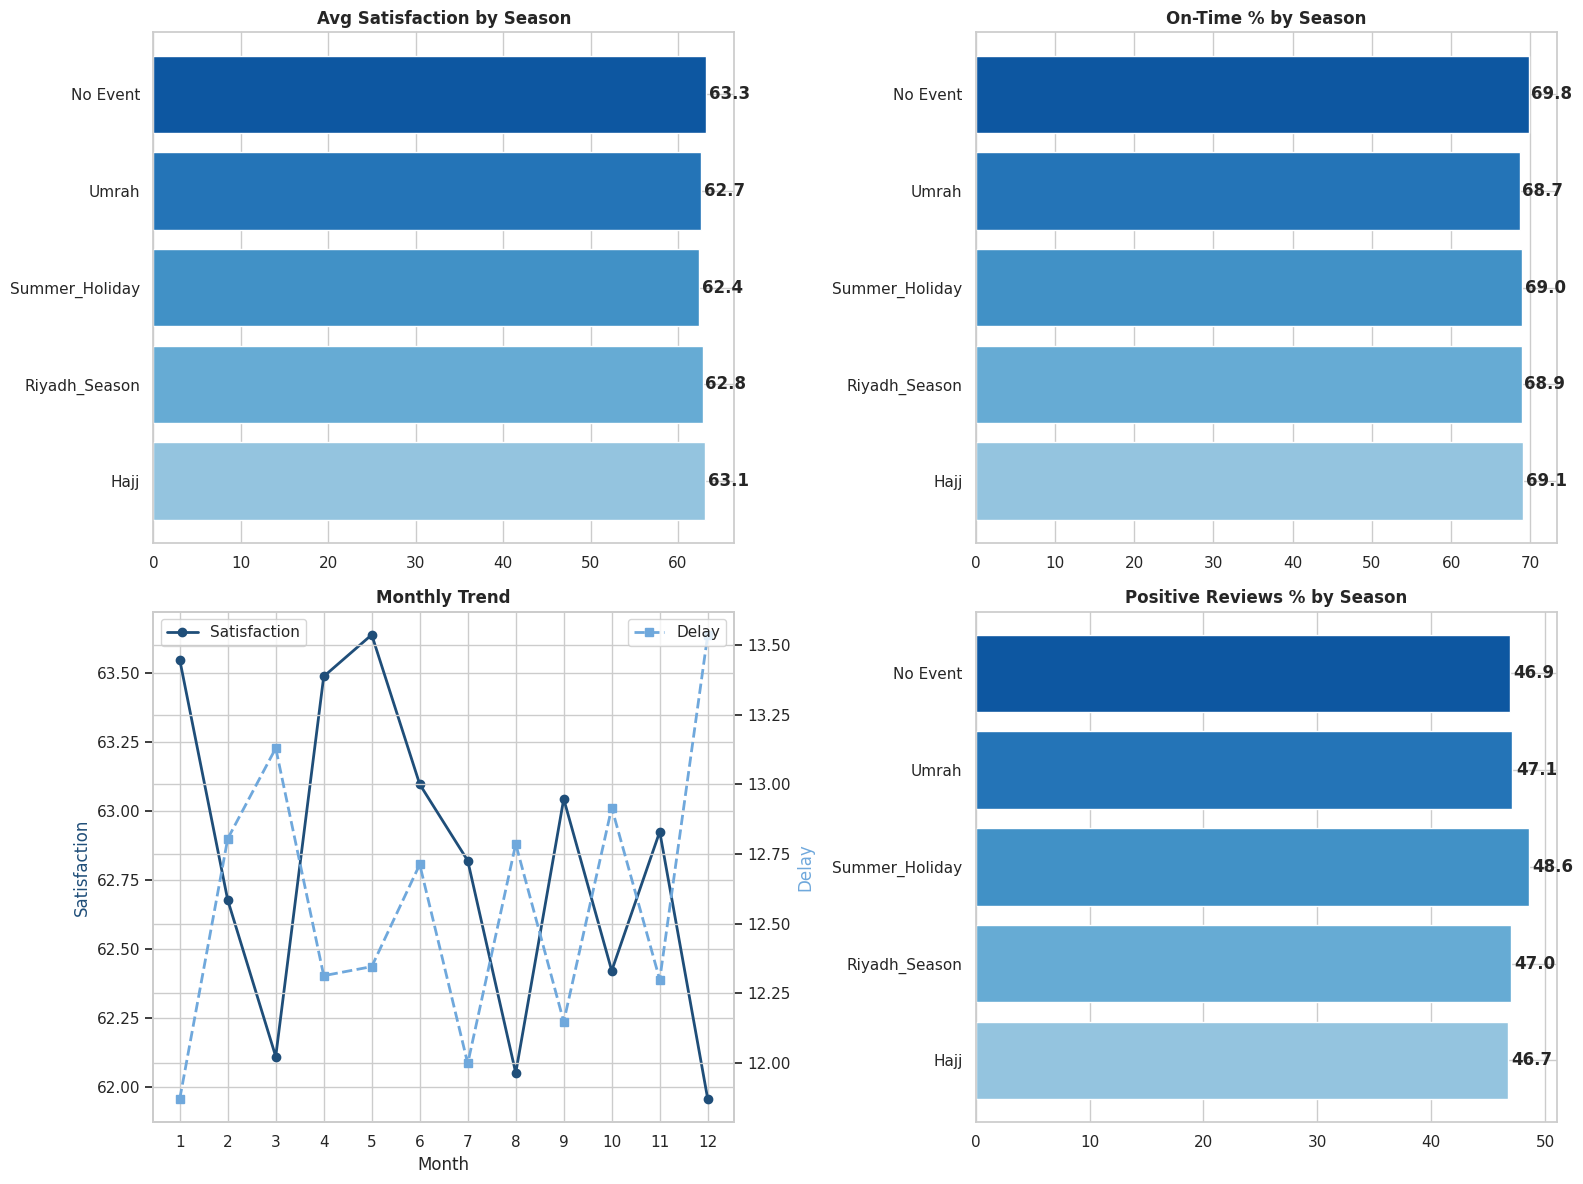

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

events = season_kpis.index.tolist()

#  درجات الأزرق
blue_palette = plt.cm.Blues(np.linspace(0.4, 0.85, len(events)))
blue_main = '#1f4e79'
blue_light = '#6fa8dc'

# --- Bar Charts ---
for ax, col, title in [
    (axes[0][0], 'avg_sat', 'Avg Satisfaction'),
    (axes[0][1], 'ontime_pct', 'On-Time %'),
    (axes[1][1], 'positive_pct', 'Positive Reviews %')
]:
    bars = ax.barh(events, season_kpis[col], color=blue_palette)
    ax.set_title(f'{title} by Season', fontweight='bold')

    for bar, val in zip(bars, season_kpis[col]):
        ax.text(
            bar.get_width()+0.3,
            bar.get_y()+bar.get_height()/2,
            f'{val:.1f}',
            va='center',
            fontweight='bold'
        )

# --- Monthly Trend ---
monthly = df.groupby('Departure_Month').agg(
    avg_sat=('Satisfaction_Index','mean'),
    avg_delay=('Delay_Minutes','mean')
).reset_index()

ax = axes[1][0]
ax2 = ax.twinx()


ax.plot(
    monthly['Departure_Month'],
    monthly['avg_sat'],
    'o-',
    color=blue_main,
    lw=2,
    label='Satisfaction'
)

ax2.plot(
    monthly['Departure_Month'],
    monthly['avg_delay'],
    's--',
    color=blue_light,
    lw=2,
    label='Delay'
)

ax.set_title('Monthly Trend', fontweight='bold')
ax.set_xlabel('Month')
ax.set_xticks(range(1,13))

ax.set_ylabel('Satisfaction', color=blue_main)
ax2.set_ylabel('Delay', color=blue_light)

ax.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.savefig('seasonal_analysis_blue.png', dpi=150, bbox_inches='tight')
plt.show()

Analysis by Airports

In [ ]:
airport_kpis = df.groupby('Destination_City').agg(
    total=('Flight_ID','count'),
    avg_sat=('Satisfaction_Index','mean'),
    ontime_pct=('Flight_Status', lambda x: (x=='On-time').mean()*100),
    avg_delay=('Delay_Minutes','mean'),
    avg_checkin=('Checkin_Time_Minutes','mean'),
    avg_boarding=('Boarding_Time_Minutes','mean'),
    avg_baggage=('Baggage_Claim_Time_Minutes','mean'),
    high_crowd_pct=('Crowd_Level', lambda x: (x=='High').mean()*100),
).round(2).sort_values('avg_sat', ascending=False)

airport_kpis['City'] = airport_kpis.index.map(airport_names)

print("Airport KPIs (ranked by satisfaction):")
print(airport_kpis.to_string())

Airport KPIs (ranked by satisfaction):
                  total  avg_sat  ontime_pct  avg_delay  avg_checkin  avg_boarding  avg_baggage  high_crowd_pct     City
Destination_City                                                                                                        
AHB                6684    63.13       69.21      12.44        19.39         28.65        32.55           42.82     Abha
JED                6677    63.12       69.10      12.55        19.21         28.45        32.52           42.80   Jeddah
RUH                6662    62.87       69.15      12.14        19.10         28.37        32.62           42.70   Riyadh
GIZ                6665    62.84       69.33      12.36        19.43         28.60        32.55           42.55    Jazan
MED                6662    62.77       69.15      12.87        19.30         28.64        32.93           43.29  Madinah
DMM                6650    62.42       68.59      12.80        19.25         28.66        32.80           43.58   

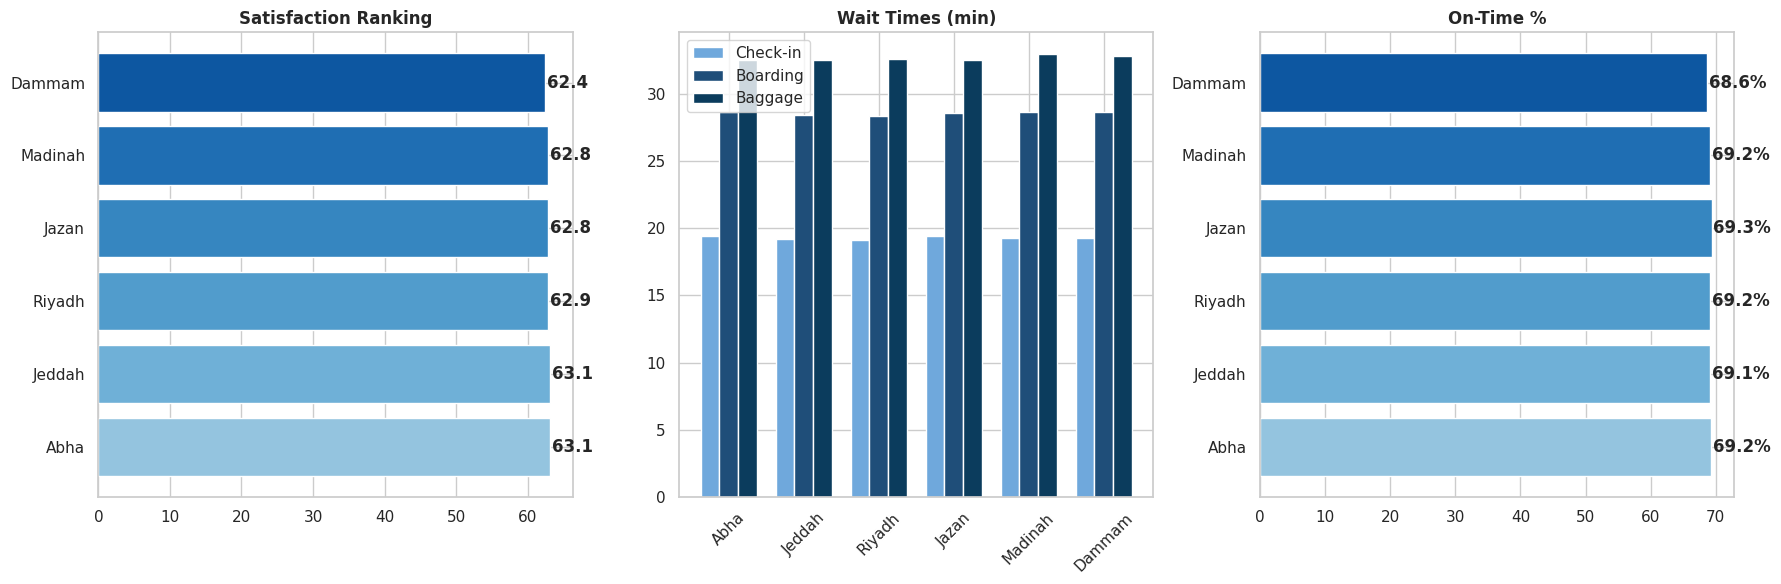

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

cities = airport_kpis.index.tolist()
city_labels = [airport_names.get(c, c) for c in cities]


blue_palette = plt.cm.Blues(np.linspace(0.4, 0.85, len(cities)))
blue_main = '#1f4e79'
blue_light = '#6fa8dc'
blue_dark = '#0b3c5d'

# --- 1) Satisfaction Ranking ---
bars = axes[0].barh(city_labels, airport_kpis['avg_sat'], color=blue_palette)
axes[0].set_title('Satisfaction Ranking', fontweight='bold')

for bar, val in zip(bars, airport_kpis['avg_sat']):
    axes[0].text(
        bar.get_width()+0.3,
        bar.get_y()+bar.get_height()/2,
        f'{val:.1f}',
        va='center',
        fontweight='bold'
    )

# --- 2) Wait Times ---
x = np.arange(len(cities))
w = 0.25

axes[1].bar(x-w, airport_kpis['avg_checkin'], w, label='Check-in', color=blue_light)
axes[1].bar(x, airport_kpis['avg_boarding'], w, label='Boarding', color=blue_main)
axes[1].bar(x+w, airport_kpis['avg_baggage'], w, label='Baggage', color=blue_dark)

axes[1].set_xticks(x)
axes[1].set_xticklabels(city_labels, rotation=45)
axes[1].set_title('Wait Times (min)', fontweight='bold')
axes[1].legend()

# --- 3) On-Time % ---
bars = axes[2].barh(city_labels, airport_kpis['ontime_pct'], color=blue_palette)
axes[2].set_title('On-Time %', fontweight='bold')

for bar, val in zip(bars, airport_kpis['ontime_pct']):
    axes[2].text(
        bar.get_width()+0.3,
        bar.get_y()+bar.get_height()/2,
        f'{val:.1f}%',
        va='center',
        fontweight='bold'
    )

plt.tight_layout()
plt.savefig('airport_analysis_blue.png', dpi=150, bbox_inches='tight')
plt.show()

Sentiment and Topic Analysis

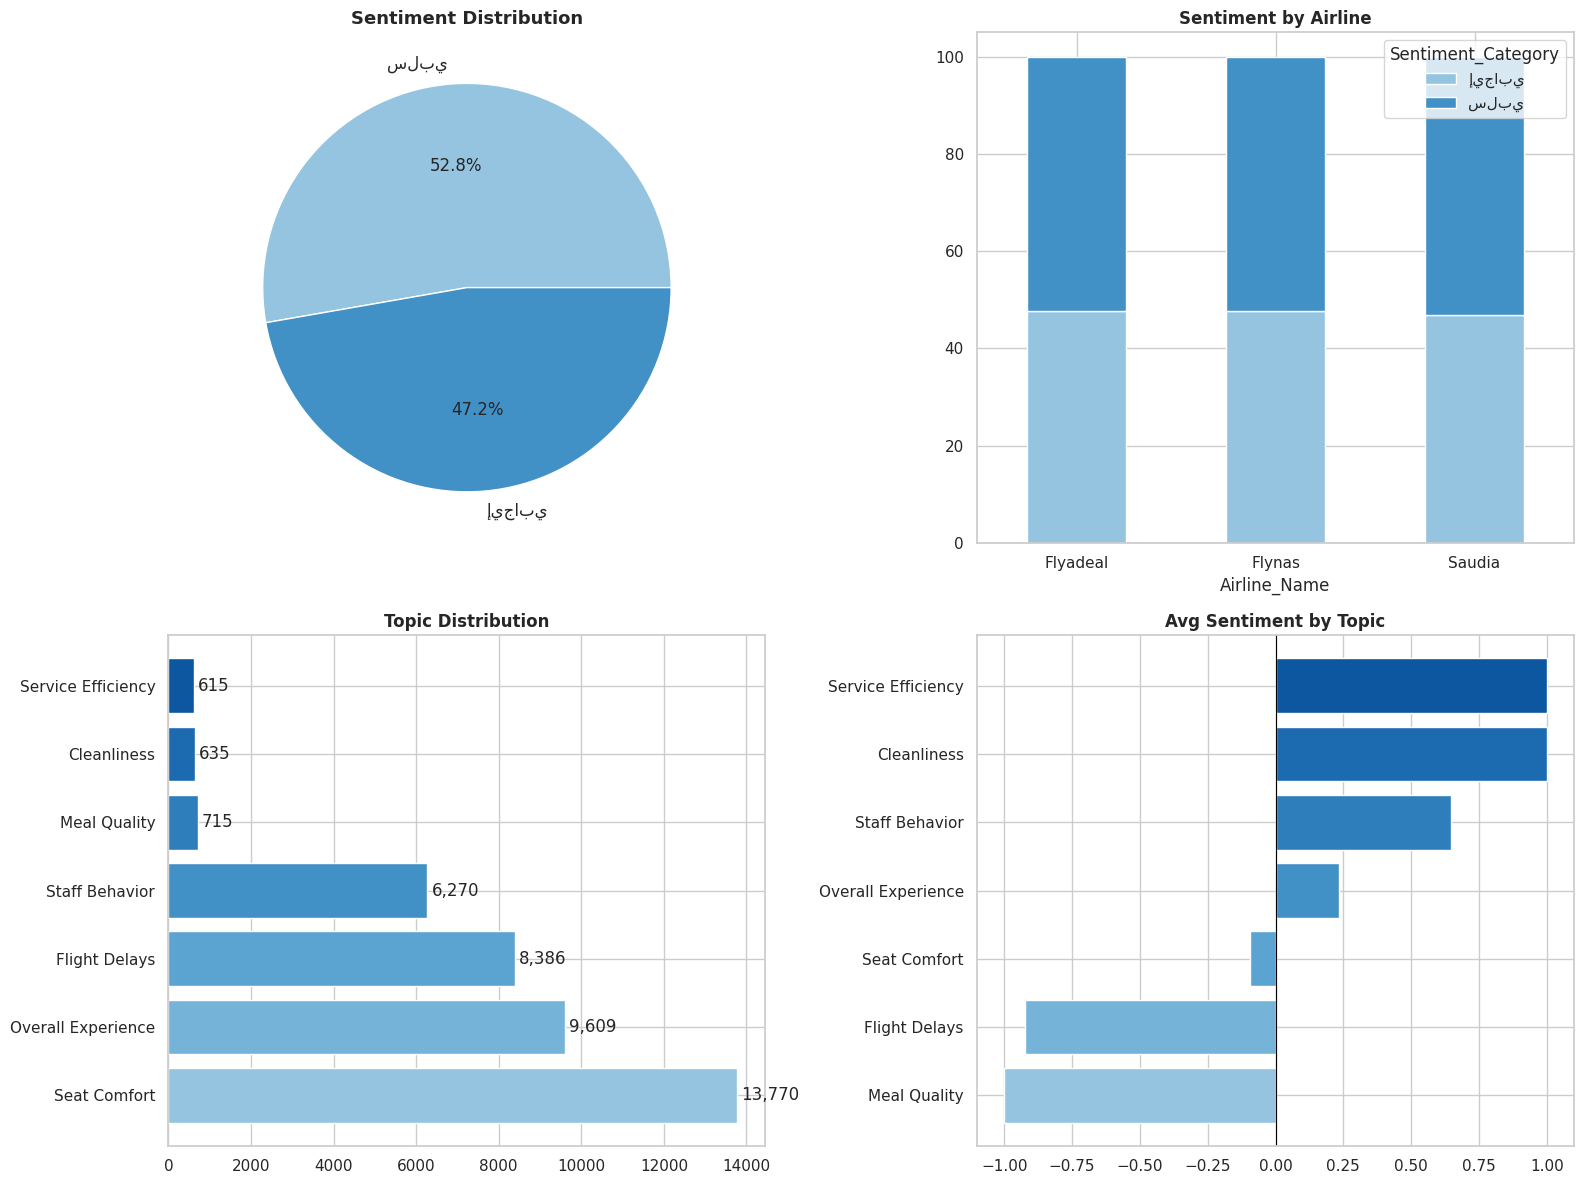

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(16, 12))


blue3 = plt.cm.Blues(np.linspace(0.4, 0.85, 3))
blue_palette = plt.cm.Blues(np.linspace(0.3, 0.9, 10))

# --- 1) Sentiment pie ---
sent = df['Sentiment_Category'].value_counts()

axes[0][0].pie(
    sent.values,
    labels=sent.index,
    autopct='%1.1f%%',
    colors=blue3,
    textprops={'fontsize':12}
)

axes[0][0].set_title('Sentiment Distribution', fontweight='bold', fontsize=13)

# --- 2) Sentiment by airline ---
sa = pd.crosstab(df['Airline_Name'], df['Sentiment_Category'], normalize='index') * 100
cols_order = [c for c in ['إيجابي','محايد','سلبي'] if c in sa.columns]

sa[cols_order].plot(
    kind='bar',
    stacked=True,
    ax=axes[0][1],
    color=blue3[:len(cols_order)]
)

axes[0][1].set_title('Sentiment by Airline', fontweight='bold')
axes[0][1].tick_params(axis='x', rotation=0)

# --- 3) Topic distribution ---
tc = df['Topic'].value_counts()

axes[1][0].barh(
    tc.index,
    tc.values,
    color=plt.cm.Blues(np.linspace(0.4, 0.85, len(tc)))
)

axes[1][0].set_title('Topic Distribution', fontweight='bold')

for i, (idx, val) in enumerate(tc.items()):
    axes[1][0].text(val+100, i, f'{val:,}', va='center')


# نحول الكاتوقري لأرقام
sentiment_map = {'إيجابي': 1, 'محايد': 0, 'سلبي': -1}
df['Sentiment_Score'] = df['Sentiment_Category'].map(sentiment_map)

ts = df.groupby('Topic')['Sentiment_Score'].mean().sort_values()

axes[1][1].barh(
    ts.index,
    ts.values,
    color=plt.cm.Blues(np.linspace(0.4, 0.85, len(ts)))
)

axes[1][1].axvline(0, color='black', lw=0.8)
axes[1][1].set_title('Avg Sentiment by Topic', fontweight='bold')

plt.tight_layout()
plt.savefig('sentiment_topic_blue.png', dpi=150, bbox_inches='tight')
plt.show()

Correlation Heatmap

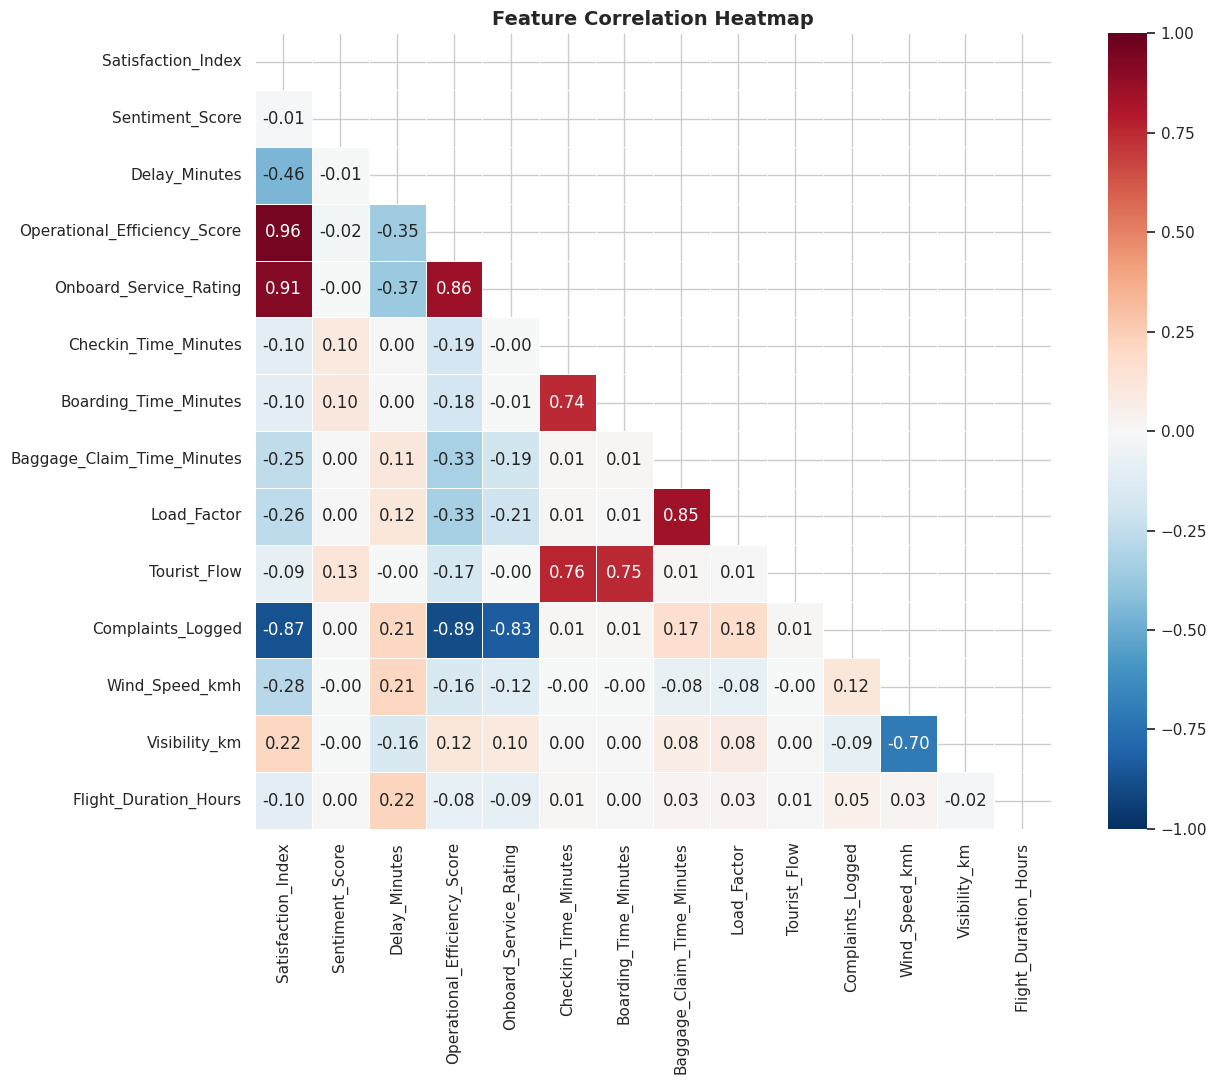

In [ ]:
corr_cols = ['Satisfaction_Index','Sentiment_Score','Delay_Minutes','Operational_Efficiency_Score',
    'Onboard_Service_Rating','Checkin_Time_Minutes','Boarding_Time_Minutes',
    'Baggage_Claim_Time_Minutes','Load_Factor','Tourist_Flow','Complaints_Logged',
    'Wind_Speed_kmh','Visibility_km','Flight_Duration_Hours']

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(df[corr_cols].corr(), dtype=bool))
sns.heatmap(df[corr_cols].corr(), mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, vmin=-1, vmax=1, ax=ax, square=True, linewidths=0.5)
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight'); plt.show()

Waiting Time Analysis

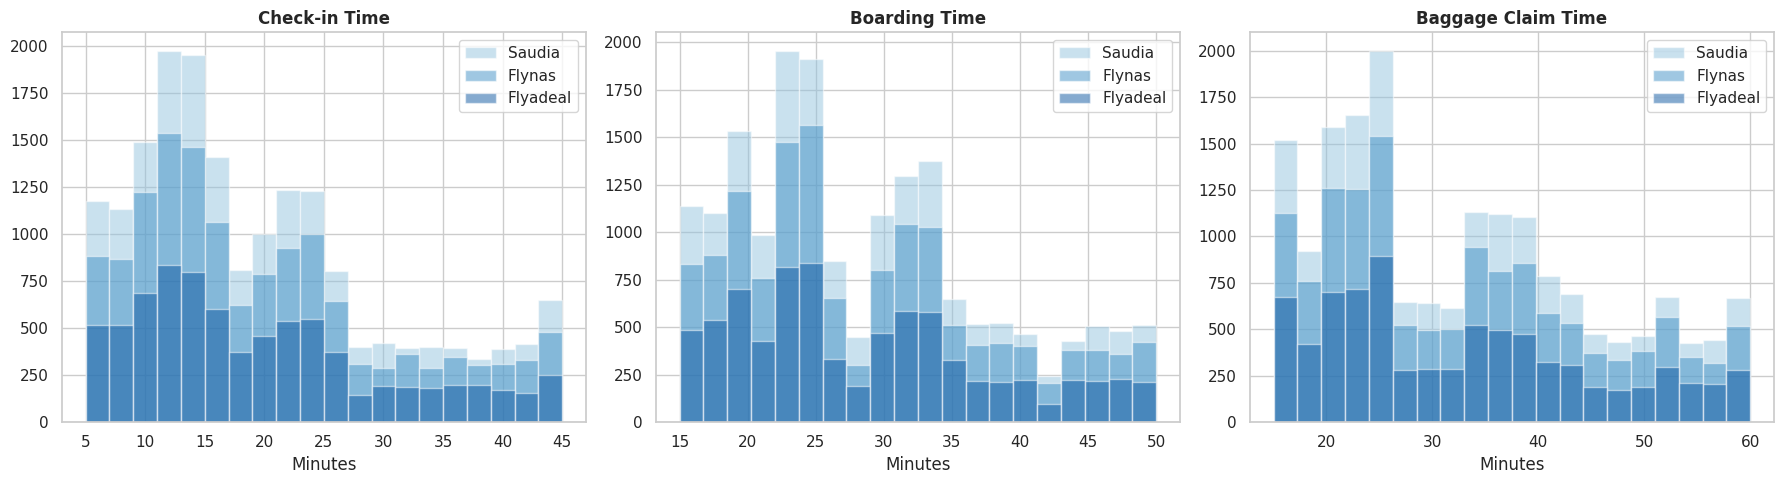

In [ ]:


fig, axes = plt.subplots(1, 3, figsize=(18, 5))

airlines = ['Saudia', 'Flynas', 'Flyadeal']


blue_palette = plt.cm.Blues(np.linspace(0.4, 0.85, len(airlines)))

for idx, (col, title) in enumerate([
    ('Checkin_Time_Minutes','Check-in'),
    ('Boarding_Time_Minutes','Boarding'),
    ('Baggage_Claim_Time_Minutes','Baggage Claim')
]):

    for airline, color in zip(airlines, blue_palette):
        axes[idx].hist(
            df[df['Airline_Name']==airline][col],
            bins=20,
            alpha=0.5,
            label=airline,
            color=color
        )

    axes[idx].set_title(f'{title} Time', fontweight='bold')
    axes[idx].set_xlabel('Minutes')
    axes[idx].legend()

plt.tight_layout()
plt.savefig('wait_times_blue.png', dpi=150, bbox_inches='tight')
plt.show()

Weather Impact Analysis

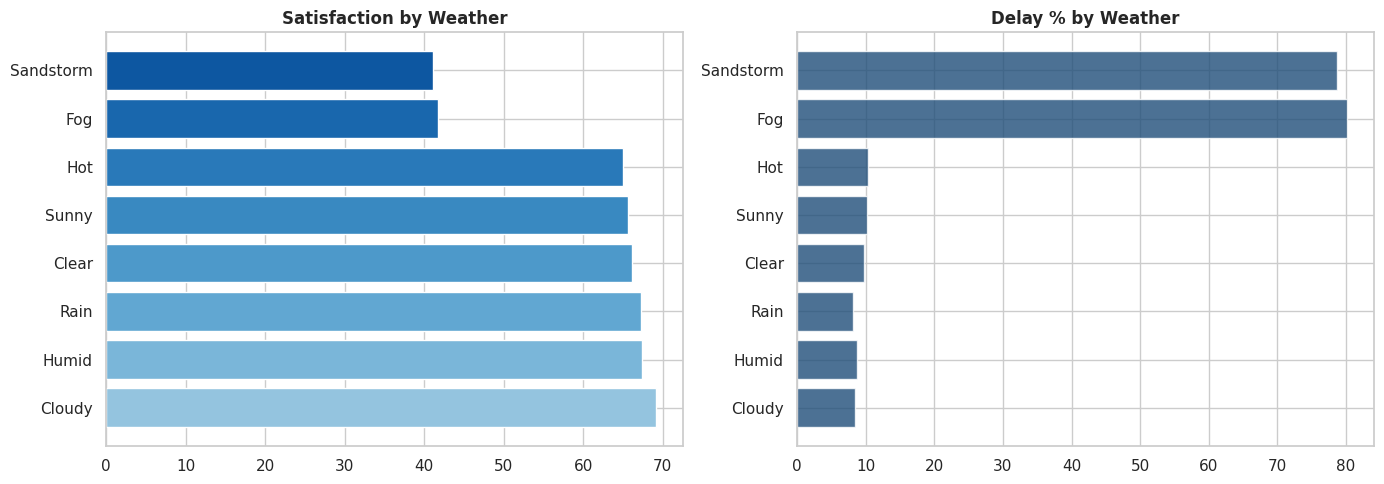

 Weather KPIs:
                    total  avg_sat  delayed_pct  avg_delay
Weather_Condition2                                        
Cloudy               3968    69.09         8.44       8.28
Humid                6565    67.38         8.79       8.39
Rain                 3958    67.21         8.08       7.54
Clear                9405    66.19         9.79       9.21
Sunny                7379    65.68        10.23       9.63
Hot                  2702    64.98        10.36       9.91
Fog                  2028    41.71        80.08      33.20
Sandstorm            3995    41.17        78.72      32.92


In [ ]:

weather_kpis = df.groupby('Weather_Condition2').agg(
    total=('Flight_ID','count'),
    avg_sat=('Satisfaction_Index','mean'),
    delayed_pct=('Flight_Status', lambda x: (x=='Delayed').mean()*100),
    avg_delay=('Delay_Minutes','mean'),
).round(2).sort_values('avg_sat', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

blue_palette = plt.cm.Blues(np.linspace(0.4, 0.85, len(weather_kpis)))
blue_main = '#1f4e79'

# --- Satisfaction by Weather ---
axes[0].barh(
    weather_kpis.index,
    weather_kpis['avg_sat'],
    color=blue_palette
)
axes[0].set_title('Satisfaction by Weather', fontweight='bold')

# --- Delay % by Weather ---
axes[1].barh(
    weather_kpis.index,
    weather_kpis['delayed_pct'],
    color=blue_main,
    alpha=0.8
)
axes[1].set_title('Delay % by Weather', fontweight='bold')

plt.tight_layout()
plt.savefig('weather_impact_blue.png', dpi=150, bbox_inches='tight')
plt.show()

print(" Weather KPIs:")
print(weather_kpis.to_string())

Customer Segmentation

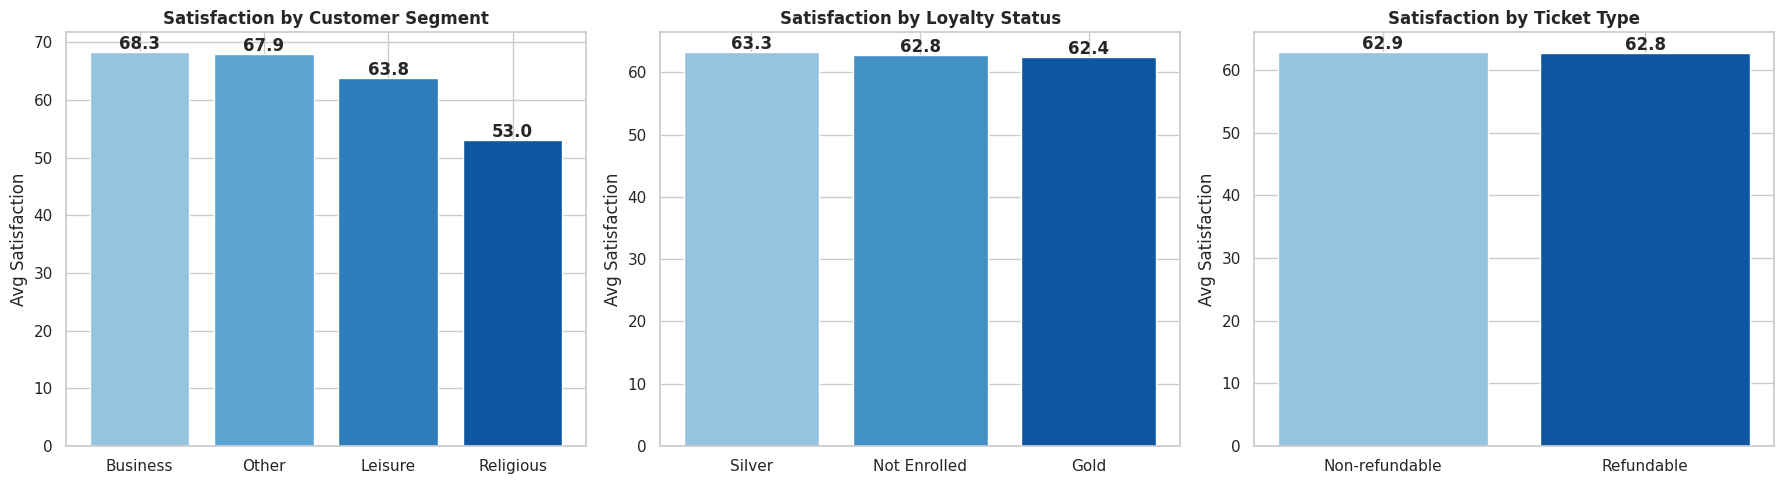

In [ ]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col, title in [
    (axes[0],'Customer_Segment','Customer Segment'),
    (axes[1],'Loyalty_Status','Loyalty Status'),
    (axes[2],'Ticket_Type','Ticket Type')
]:
    grp = df.groupby(col)['Satisfaction_Index'].mean().sort_values(ascending=False)

    #  درجات الأزرق حسب عدد الفئات
    colors = plt.cm.Blues(np.linspace(0.4, 0.85, len(grp)))

    ax.bar(grp.index, grp.values, color=colors)

    ax.set_title(f'Satisfaction by {title}', fontweight='bold')
    ax.set_ylabel('Avg Satisfaction')

    for i, (idx_val, val) in enumerate(grp.items()):
        ax.text(i, val+0.5, f'{val:.1f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('customer_analysis_blue.png', dpi=150, bbox_inches='tight')
plt.show()

KPIs Summary

In [ ]:
print("=" * 70)
print("SAMA PLATFORM — KPI SUMMARY")
print("=" * 70)
print(f"\n OVERALL:")
print(f"  Total Flights:       {len(df):,}")
print(f"  On-Time Rate:        {(df['Flight_Status']=='On-time').mean()*100:.1f}%")
print(f"  Avg Satisfaction:    {df['Satisfaction_Index'].mean():.1f}/100")
print(f"  Avg Sentiment:       {df['Sentiment_Score'].mean():.3f}")
print(f"  Positive Reviews:    {(df['Sentiment_Category']=='إيجابي').mean()*100:.1f}%")
print(f"  Avg Delay (delayed): {df[df['Flight_Status']=='Delayed']['Delay_Minutes'].mean():.0f} min")
print(f"  Complaint Rate:      {(df['Complaints_Logged']>0).mean()*100:.1f}%")

print(f"\n RANKINGS:")
print(f"  Best airline (satisfaction):  {airline_kpis['avg_satisfaction'].idxmax()} ({airline_kpis['avg_satisfaction'].max():.1f})")
print(f"  Worst airline:                {airline_kpis['avg_satisfaction'].idxmin()} ({airline_kpis['avg_satisfaction'].min():.1f})")
best_ap = airport_kpis['avg_sat'].idxmax()
worst_ap = airport_kpis['avg_sat'].idxmin()
print(f"  Best airport:  {airport_names.get(best_ap,best_ap)} ({airport_kpis.loc[best_ap,'avg_sat']:.1f})")
print(f"  Worst airport: {airport_names.get(worst_ap,worst_ap)} ({airport_kpis.loc[worst_ap,'avg_sat']:.1f})")
print(f"  Top complaint: {df['Topic'].value_counts().idxmax()} ({df['Topic'].value_counts().iloc[0]:,})")

SAMA PLATFORM — KPI SUMMARY

 OVERALL:
  Total Flights:       40,000
  On-Time Rate:        69.1%
  Avg Satisfaction:    62.9/100
  Avg Sentiment:       -0.055
  Positive Reviews:    47.2%
  Avg Delay (delayed): 63 min
  Complaint Rate:      20.8%

 RANKINGS:
  Best airline (satisfaction):  Flyadeal (62.9)
  Worst airline:                Flynas (62.7)
  Best airport:  Abha (63.1)
  Worst airport: Dammam (62.4)
  Top complaint: Seat Comfort (13,770)


---
## 12. Export KPIs

In [ ]:
!pip install xlsxwriter -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 7.0 MB/s eta 0:00:00


In [ ]:
with pd.ExcelWriter('SAMA_Phase4_KPIs.xlsx', engine='xlsxwriter') as writer:
    airline_kpis.to_excel(writer, sheet_name='Airline_KPIs')
    airport_kpis.to_excel(writer, sheet_name='Airport_KPIs')
    season_kpis.to_excel(writer, sheet_name='Season_KPIs')
    weather_kpis.to_excel(writer, sheet_name='Weather_KPIs')

    df.groupby('Route').agg(total=('Flight_ID','count'),avg_sat=('Satisfaction_Index','mean'),
        avg_delay=('Delay_Minutes','mean'),ontime_pct=('Flight_Status',lambda x:(x=='On-time').mean()*100),
        avg_sentiment=('Sentiment_Score','mean')).round(2).sort_values('avg_sat',ascending=False).to_excel(writer, sheet_name='Route_KPIs')

    df.groupby(['Departure_Year','Departure_Month']).agg(total=('Flight_ID','count'),
        avg_sat=('Satisfaction_Index','mean'),avg_delay=('Delay_Minutes','mean'),
        ontime_pct=('Flight_Status',lambda x:(x=='On-time').mean()*100),
        avg_sentiment=('Sentiment_Score','mean')).round(2).to_excel(writer, sheet_name='Monthly_KPIs')

    df.groupby(['Airline_Name','Topic']).agg(count=('Flight_ID','count'),
        avg_sentiment=('Sentiment_Score','mean'),
        positive_pct=('Sentiment_Category',lambda x:(x=='إيجابي').mean()*100)).round(2).to_excel(writer, sheet_name='Topic_Airline_KPIs')